- do initial EDA?
- how many data jobs are there in the data set?
- how many work years are represented?
- which countries exist in this data set?
- what type of company size are there? 
- ratio of remot work vs office?
- average salaries per job role? 
- median salaries per job role?
- seniority level and average salaries?
- remote work and average salaries?
- company location and average salaries?
- clean job titles?
- do different visualizations?
- export visualizations?
- export cleaned data?


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
df = pd.read_csv("salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


In [7]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           16534 non-null  int64
 1   experience_level    16534 non-null  str  
 2   employment_type     16534 non-null  str  
 3   job_title           16534 non-null  str  
 4   salary              16534 non-null  int64
 5   salary_currency     16534 non-null  str  
 6   salary_in_usd       16534 non-null  int64
 7   employee_residence  16534 non-null  str  
 8   remote_ratio        16534 non-null  int64
 9   company_location    16534 non-null  str  
 10  company_size        16534 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.4 MB
None


In [8]:
print(df.head(10))

   work_year experience_level employment_type                  job_title  \
0       2024               SE              FT                AI Engineer   
1       2024               SE              FT                AI Engineer   
2       2024               SE              FT              Data Engineer   
3       2024               SE              FT              Data Engineer   
4       2024               SE              FT  Machine Learning Engineer   
5       2024               SE              FT  Machine Learning Engineer   
6       2024               MI              FT                ML Engineer   
7       2024               MI              FT                ML Engineer   
8       2024               EN              FT               Data Analyst   
9       2024               EN              FT               Data Analyst   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0  202730             USD         202730                 US             0   
1   92118

- descriptive statistic or summary statistic 

In [9]:
print(df.describe()) 

          work_year        salary  salary_in_usd  remote_ratio
count  16534.000000  1.653400e+04   16534.000000  16534.000000
mean    2023.226866  1.637270e+05  149686.777973     32.003750
std        0.713558  3.402057e+05   68505.293156     46.245158
min     2020.000000  1.400000e+04   15000.000000      0.000000
25%     2023.000000  1.017630e+05  101125.000000      0.000000
50%     2023.000000  1.422000e+05  141300.000000      0.000000
75%     2024.000000  1.872000e+05  185900.000000    100.000000
max     2024.000000  3.040000e+07  800000.000000    100.000000


In [10]:
# T stands for transpose, which means that the rows and columns will be swapped in the output.
#  This can make it easier to read the summary statistics for each column, 
# especially when there are many columns in the DataFrame.

df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,16534.0,2023.226866,0.713558,2020.0,2023.0,2023.0,2024.0,2024.0
salary,16534.0,163726.962683,340205.744183,14000.0,101763.0,142200.0,187200.0,30400000.0
salary_in_usd,16534.0,149686.777973,68505.293156,15000.0,101125.0,141300.0,185900.0,800000.0
remote_ratio,16534.0,32.003750,46.245158,0.0,0.0,0.0,100.0,100.0


In [11]:
print(f"Rows: {df.shape[0]}, Cols: {df.shape[1]}")

Rows: 16534, Cols: 11


In [12]:
print(df.value_counts())

work_year  experience_level  employment_type  job_title                  salary   salary_currency  salary_in_usd  employee_residence  remote_ratio  company_location  company_size
2023       SE                FT               Applied Scientist          136000   USD              136000         US                  0             US                L               54
                                              Machine Learning Engineer  204500   USD              204500         US                  0             US                M               35
                                                                         142200   USD              142200         US                  0             US                M               34
                                              Applied Scientist          222200   USD              222200         US                  0             US                L               29
                                              Data Scientist             185900  

[[<Axes: title={'center': 'work_year'}>
  <Axes: title={'center': 'salary'}>]
 [<Axes: title={'center': 'salary_in_usd'}>
  <Axes: title={'center': 'remote_ratio'}>]]


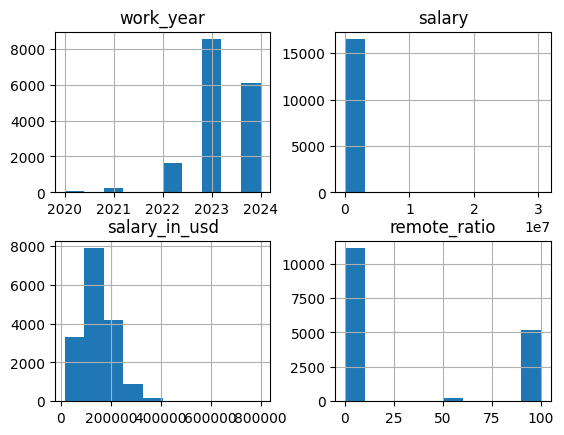

In [13]:
print(df.hist())

In [14]:

print(df.columns)

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')


In [15]:
#how many data jobs are there in the data set?
# Rekna de olika jobben i data_jobs
data_jobs = df[df['job_title'].str.contains("Data|AI|Analyst|engineer|Machine Learning Engineer|", case=False, na=False)]
antal_data_jobs = len(data_jobs)
print(f"Antal data jobb: {antal_data_jobs}")

Antal data jobb: 16534


In [16]:
# how many work years are represented?
antal_år = df['work_year'].nunique()
print(f"Antal olika arbetsår: {antal_år}")


Antal olika arbetsår: 5


In [17]:
år_lista = df['work_year'].unique()
print(f"År i datasetet: {år_lista}")

År i datasetet: [2024 2022 2023 2020 2021]


In [18]:
#räkna antal länder 
länder = df['company_location'].unique()
print("Länder i datasetet:", länder)
print("Antal unika länder i datasetet:", len(länder))

Länder i datasetet: <StringArray>
['US', 'AU', 'GB', 'CA', 'NL', 'LT', 'DK', 'FR', 'ZA', 'NZ', 'AR', 'ES', 'KE',
 'LV', 'IN', 'DE', 'IL', 'FI', 'AT', 'BR', 'CH', 'AE', 'PL', 'SA', 'UA', 'EG',
 'PH', 'TR', 'OM', 'MX', 'PT', 'BA', 'IT', 'AS', 'IE', 'EE', 'MT', 'HU', 'LB',
 'RO', 'VN', 'NG', 'LU', 'GI', 'CO', 'SI', 'GR', 'MU', 'RU', 'KR', 'CZ', 'QA',
 'GH', 'SE', 'AD', 'EC', 'NO', 'JP', 'HK', 'CF', 'SG', 'TH', 'HR', 'AM', 'PK',
 'IR', 'BS', 'PR', 'BE', 'ID', 'MY', 'HN', 'DZ', 'IQ', 'CN', 'CL', 'MD']
Length: 77, dtype: str
Antal unika länder i datasetet: 77


In [19]:
# company_size - small, medium, large

print(df['company_size'].value_counts())    

company_size
M    15306
L     1040
S      188
Name: count, dtype: int64


In [20]:
print(f"number of employees in dataset:{len(df)}")

number of employees in dataset:16534


## Explore different categirical columns 
- experience level 
- job_title 
- emplyment_type 
- employee_residence
- remot_ratio
...  

In [21]:
df["experience_level"].value_counts()

experience_level
SE    10670
MI     4038
EN     1325
EX      501
Name: count, dtype: int64

<Axes: xlabel='experience_level'>

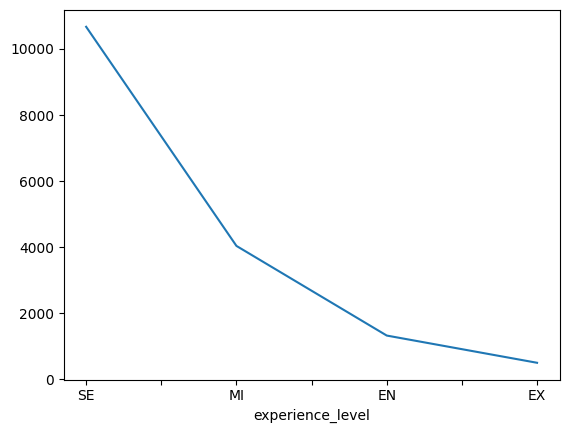

In [22]:
df["experience_level"].value_counts().plot()

<Axes: title={'center': 'employees by Experience level in data feelds'}, xlabel='Experience level', ylabel='number of employees'>

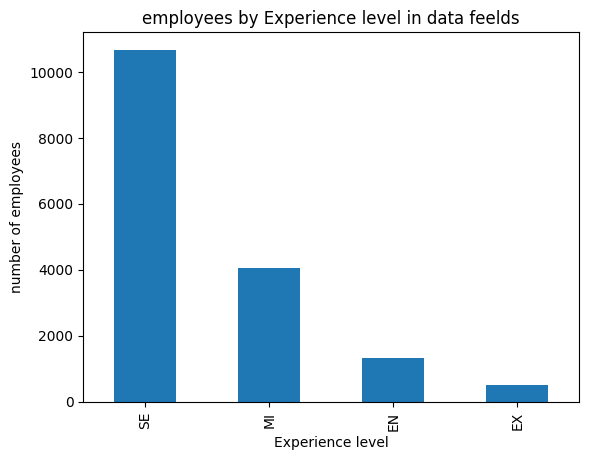

In [23]:
#df["experience_level"].value_counts().plot.bar()
ax = df["experience_level"].value_counts().plot(
    kind="bar", 
    title="employees by Experience level in data feelds", 
    xlabel="Experience level", 
    ylabel="number of employees"
)

ax 

In [24]:
fig = ax.get_figure()
fig.savefig("employees_senior_level.png",dpi=300) 

# Data cleaning 
 
- similar titles put toghether 


In [25]:
df["job_title"].value_counts()


job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
                             ... 
Deep Learning Researcher        1
Marketing Data Engineer         1
Data Science Tech Lead          1
Principal Data Architect        1
Cloud Data Architect            1
Name: count, Length: 155, dtype: int64

In [26]:
import duckdb

duckdb.sql("""--sql
    FROM df
    WHERE job_title ILIKE 'data scie%'
"""
).df()["job_title"].value_counts()

job_title
Data Scientist               3314
Data Science                  271
Data Science Manager          122
Data Science Consultant        83
Data Science Engineer          29
Data Science Lead              26
Data Science Practitioner      16
Data Science Director           8
Data Science Analyst            4
Data Scientist Lead             2
Data Science Tech Lead          1
Name: count, dtype: int64

In [28]:
duckdb.sql("""
SELECT 
    * EXCLUDE(job_title),
    CASE 
        WHEN job_title ILIKE 'data scie%' THEN 'Data Scientist'
        ELSE job_title
    END AS job_title       
FROM df
""").df()["job_title"].value_counts()

job_title
Data Scientist               3876
Data Engineer                3464
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
                             ... 
BI Data Engineer                1
Deep Learning Researcher        1
Marketing Data Engineer         1
Principal Data Architect        1
Cloud Data Architect            1
Name: count, Length: 145, dtype: int64